# Week 1 Homework: Fine-tuning ModernBERT-base

**ECBS5200 — Practical Deep Learning Engineering**

This notebook fine-tunes ModernBERT-base on the full consumer complaints
dataset. Unlike the lab, this is not a "run all" notebook — you will make
choices, fill in values, fix a bug, run an experiment, and draft your
weekly memo inline.

**Expected time:** ~5-6 hours on a Kaggle T4 GPU.

**How to use this notebook:**
- Cells marked **GUIDED** are provided for you. Read and run them.
- Cells marked **INTERACTIVE** require you to fill in values or write answers.
- Look for `___` — these are placeholders that will cause a NameError if
  you run the cell without filling them in.
- The last section is your memo draft. Write your observations there.

## Kaggle setup (do this first!)

Before running any cells, go to **Settings** (gear icon, right sidebar):
1. Set **Persistence** to **"Variables and Files"** — training takes ~40 min, don't lose it to a disconnect
2. Set **Internet** to **On** — needed to download the course repo and model weights
3. Set **Accelerator** to **GPU T4** — needed for training

If you saved `week1_results.csv` from the lab, upload it here (drag into
the file browser). If you don't have it, the baseline numbers are loaded
automatically.

When you're done, **download your checkpoint and `week1_results.csv`**
before closing the session.

---
## Part 1: Setup and Configuration (~30 min)
---

In [ ]:
# GUIDED: Install dependencies
import sys
import subprocess
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "transformers>=4.53", "datasets", "accelerate", "scikit-learn",
    "matplotlib", "pandas", "tqdm",
])

0

In [ ]:
# GUIDED: Imports
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load course utilities — works both locally (in the repo) and on Kaggle
REPO_PATH = Path("../..").resolve()
if not (REPO_PATH / "utils" / "data_utils.py").exists():
    REPO_PATH = Path("/tmp/course")
    if not REPO_PATH.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/earino/applied-deep-learning.git", str(REPO_PATH)])
sys.path.insert(0, str(REPO_PATH))

from utils.data_utils import (
    load_course_data, LABEL_LIST, NUM_LABELS, LABEL_TO_ID, ID_TO_LABEL, MAX_LENGTH,
)

### Device setup

In [ ]:
# GUIDED: Reproducibility and device setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = props.total_memory / 1024**3
    # T4 GPUs report bf16 support but lack hardware acceleration for it.
    # Use fp16 unless we're on an Ampere+ GPU (compute capability >= 8.0).
    cc = torch.cuda.get_device_capability()
    AMP_DTYPE = torch.bfloat16 if cc[0] >= 8 else torch.float16
else:
    gpu_name = "CPU"
    gpu_mem = 0
    AMP_DTYPE = torch.float32

print(f"Device:     {device}")
print(f"GPU:        {gpu_name} ({gpu_mem:.1f} GB)" if torch.cuda.is_available() else "GPU: none")
print(f"AMP dtype:  {AMP_DTYPE}")

Device:     cuda
GPU:        Tesla T4 (14.6 GB)
AMP dtype:  torch.float16


### Load tokenizer

In [ ]:
# GUIDED: Load tokenizer
MODEL_NAME = "answerdotai/ModernBERT-base"
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Loading tokenizer: answerdotai/ModernBERT-base


### INTERACTIVE: Choose your learning rate

Fine-tuning typically uses learning rates between 1e-5 and 5e-5.
The slides discussed why: too high causes catastrophic forgetting
(the pretrained weights get destroyed), too low causes underfitting
(the model barely moves from its starting point).

Choose a value and justify your choice in the comment.

In [ ]:
# INTERACTIVE: Fill in your learning rate choice.
# This cell will raise a NameError if you don't fill it in.
LEARNING_RATE = 3e-5  # YOUR CHOICE — fill in a value between 1e-5 and 5e-5
# Why this value? YOUR REASON: For what I know, this often works well as a starting point. It allows the model to make significant updates to the weights without being too aggressive, which can help in achieving good performance on the task.

In [ ]:
# GUIDED: Other configuration (these are given)
BATCH_SIZE = 32
NUM_EPOCHS = 2
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.10  # 10% of steps for linear warmup

print(f"Config: lr={LEARNING_RATE}, bs={BATCH_SIZE}, epochs={NUM_EPOCHS}")
print(f"  weight_decay={WEIGHT_DECAY}, warmup={WARMUP_FRACTION}")

Config: lr=3e-05, bs=32, epochs=2
  weight_decay=0.01, warmup=0.1


### Load and tokenize data

In [ ]:
# GUIDED: Load and tokenize the full dataset
print("Loading and tokenizing dataset...")
t0 = time.time()
train_ds, val_ds, test_ds = load_course_data(tokenizer=tokenizer, max_length=MAX_LENGTH)
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
print(f"  Columns: {train_ds.column_names}")

Loading and tokenizing dataset...


README.md:   0%|          | 0.00/606 [00:00<?, ?B/s]

data/train-00000-of-00001-f6ccf6490f1232(…):   0%|          | 0.00/10.2M [00:00<?, ?B/s]

data/test-00000-of-00001-0b18a4667c07409(…):   0%|          | 0.00/3.39M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/64292 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/21439 [00:00<?, ? examples/s]

Map:   0%|          | 0/57846 [00:00<?, ? examples/s]

Map:   0%|          | 0/6430 [00:00<?, ? examples/s]

Map:   0%|          | 0/21432 [00:00<?, ? examples/s]

  Done in 39.6s
  Train: 57,846  Val: 6,430  Test: 21,432
  Columns: ['text', 'label', 'label_name', 'input_ids', 'attention_mask']


### DataLoader setup

In [ ]:
# GUIDED: PyTorch Dataset wrapper and DataLoaders
class ComplaintDataset(Dataset):
    """Wraps a HuggingFace Dataset for PyTorch DataLoader."""
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(item["label"], dtype=torch.long),
        }

train_loader = DataLoader(
    ComplaintDataset(train_ds), batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    ComplaintDataset(val_ds), batch_size=BATCH_SIZE, shuffle=False,
)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# Sanity check: inspect one batch
sample = next(iter(train_loader))
for k, v in sample.items():
    print(f"  {k}: {v.shape} {v.dtype}")

Train batches: 1808  |  Val batches: 201
  input_ids: torch.Size([32, 128]) torch.int64
  attention_mask: torch.Size([32, 128]) torch.int64
  labels: torch.Size([32]) torch.int64


### Load the model

We add a 113-class classification head on top of ModernBERT-base.
`attn_implementation="sdpa"` uses PyTorch's Scaled Dot-Product Attention,
which is faster and more memory-efficient on T4. The classification head
is randomly initialized — only the encoder has pretrained weights.

In [ ]:
# GUIDED: Load model with classification head
print(f"Loading {MODEL_NAME} with {NUM_LABELS}-class head...")
t0 = time.time()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    attn_implementation="sdpa",
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"  {total_params:,} parameters | loaded in {time.time()-t0:.1f}s")
if torch.cuda.is_available():
    print(f"  GPU memory (model): {torch.cuda.memory_allocated() / 1024**2:.0f} MB")

Loading answerdotai/ModernBERT-base with 113-class head...


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  149,691,761 parameters | loaded in 13.3s
  GPU memory (model): 591 MB


---
## Part 2: Training (~40 min, mostly passive)
---

### Optimizer and scheduler

**Why a small learning rate?** Pretrained transformer weights are already in
a good region of parameter space. A large learning rate (like 1e-3) would
destroy the pretrained representations. The value you chose above should be
in the 1e-5 to 5e-5 range — the standard for BERT-family fine-tuning.

**Linear warmup** over 10% of steps prevents early instability — the randomly
initialized classification head needs a few steps to produce reasonable
gradients before the full learning rate kicks in.

In [ ]:
# GUIDED: Optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRACTION)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_scaler = (AMP_DTYPE == torch.float16)
scaler = GradScaler("cuda", enabled=use_scaler)

print(f"Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")
print(f"GradScaler: {'on' if use_scaler else 'off'}")

Total steps: 3616  |  Warmup steps: 361
GradScaler: on


### Training loop

The raw loop: forward pass, compute loss, backward pass, optimizer step,
scheduler step. We track loss at every step for the learning curve.

Key patterns to notice:
- `model.train()` enables dropout
- Mixed precision via `autocast` for speed
- Loss is tracked per step for the learning curve plot

### INTERACTIVE: Before you train

Before running the training loop, think about your expectations.
Look at the baseline results from the lab.

- What macro F1 did TF-IDF achieve?
- What do you predict the fine-tuned model will get?
- Why?

In [ ]:
# INTERACTIVE: Fill in your predictions before running training.
tfidf_macro_f1_from_lab = 0.1334  # What was the TF-IDF macro F1? (e.g., 0.13)
my_predicted_macro_f1 = 0.28    # What do you predict for fine-tuning? (e.g., 0.30)
# Why? YOUR REASON: Fine-tuning a model allow it to learn task-specific patterns, which can improve the performance.

In [ ]:
# GUIDED: Training loop
print("=" * 60)
print(f"TRAINING: {NUM_EPOCHS} epoch(s), {len(train_loader)} batches/epoch")
print("=" * 60)

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

step_losses = []
training_start = time.time()
log_every = max(1, len(train_loader) // 10)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_start = time.time()
    running_loss = 0.0
    n_samples = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=True)
    for batch_idx, batch in enumerate(progress):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        step_loss = loss.item()
        step_losses.append(step_loss)
        running_loss += step_loss * labels.size(0)
        n_samples += labels.size(0)

        if (batch_idx + 1) % log_every == 0:
            avg_loss = running_loss / n_samples
            current_lr = scheduler.get_last_lr()[0]
            progress.set_postfix(loss=f"{avg_loss:.4f}", lr=f"{current_lr:.2e}")

    epoch_time = time.time() - epoch_start
    epoch_loss = running_loss / n_samples
    print(f"  Epoch {epoch} done: loss={epoch_loss:.4f}, time={epoch_time:.0f}s")

TRAINING: 2 epoch(s), 1808 batches/epoch


Epoch 1/2:   0%|          | 0/1808 [00:00<?, ?it/s]

W0424 15:17:09.272000 1535 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


  Epoch 1 done: loss=2.1522, time=1131s


Epoch 2/2:   0%|          | 0/1808 [00:00<?, ?it/s]

  Epoch 2 done: loss=1.4308, time=1212s


### Validation

In [ ]:
# GUIDED: Evaluate on validation set
print("\nEvaluating on validation set...")
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )

        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_acc = accuracy_score(all_labels, all_preds)
val_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
val_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

total_time = time.time() - training_start
peak_mem = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0

print(f"\nResults after {NUM_EPOCHS} epoch(s):")
print(f"  Accuracy:     {val_acc:.4f}")
print(f"  Macro F1:     {val_macro_f1:.4f}")
print(f"  Weighted F1:  {val_weighted_f1:.4f}")
print(f"  Total time:   {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"  Peak GPU mem: {peak_mem:.0f} MB")


Evaluating on validation set...


Validation:   0%|          | 0/201 [00:00<?, ?it/s]


Results after 2 epoch(s):
  Accuracy:     0.5712
  Macro F1:     0.2092
  Weighted F1:  0.5368
  Total time:   2957s (49.3 min)
  Peak GPU mem: 4257 MB


### Learning curve

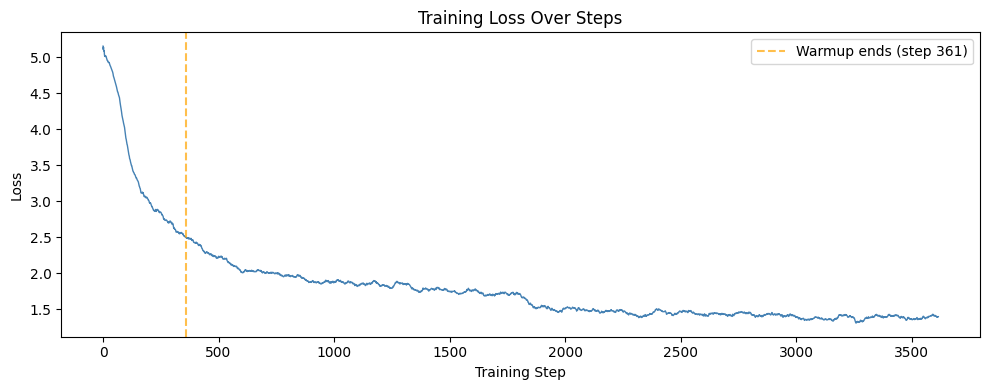

In [ ]:
# GUIDED: Plot training loss over steps
fig, ax = plt.subplots(figsize=(10, 4))

window = max(1, len(step_losses) // 50)
smoothed = pd.Series(step_losses).rolling(window, min_periods=1).mean()

ax.plot(smoothed, color="steelblue", linewidth=1)
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Over Steps")
ax.axvline(warmup_steps, color="orange", linestyle="--", alpha=0.7,
           label=f"Warmup ends (step {warmup_steps})")
ax.legend()
plt.tight_layout()
plt.show()

### Save checkpoint

In [ ]:
# GUIDED: Save checkpoint
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

checkpoint_path = CHECKPOINT_DIR / "modernbert_final.pt"
print(f"Saving checkpoint to {checkpoint_path}...")

torch.save({
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "step_losses": step_losses,
    "val_accuracy": val_acc,
    "val_macro_f1": val_macro_f1,
    "val_weighted_f1": val_weighted_f1,
    "model_name": MODEL_NAME,
    "num_labels": NUM_LABELS,
    "max_length": MAX_LENGTH,
    "label2id": LABEL_TO_ID,
    "id2label": ID_TO_LABEL,
    "seed": SEED,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
}, checkpoint_path)

ckpt_size = checkpoint_path.stat().st_size / 1024**2
print(f"  Saved ({ckpt_size:.0f} MB)")

Saving checkpoint to checkpoints/modernbert_final.pt...
  Saved (1713 MB)


---
## Part 3: Analysis (~2-3 hours — this is the meat)
---

### Per-class F1 for the fine-tuned model

In [ ]:
# GUIDED: Compute per-class F1 scores for the fine-tuned model
ft_report = classification_report(
    all_labels, all_preds,
    labels=list(range(NUM_LABELS)),
    target_names=LABEL_LIST,
    zero_division=0,
    output_dict=True,
)

ft_class_f1 = {}
for i in range(NUM_LABELS):
    label_name = LABEL_LIST[i]
    ft_class_f1[label_name] = ft_report[label_name]["f1-score"]

print(f"Computed per-class F1 for {len(ft_class_f1)} classes")
print(f"Classes with F1 > 0: {sum(1 for f in ft_class_f1.values() if f > 0)}")
print(f"Classes with F1 = 0: {sum(1 for f in ft_class_f1.values() if f == 0)}")

Computed per-class F1 for 113 classes
Classes with F1 > 0: 63
Classes with F1 = 0: 50


### INTERACTIVE: Load baseline and build comparison

Load the baseline results from `week1_results.csv` (saved in the lab).
Then compute per-class F1 for the baseline so we can compare side by side.

In [ ]:
# GUIDED: Load baseline results
baseline_csv = Path("week1_results.csv")
if baseline_csv.exists():
    baseline_df = pd.read_csv(baseline_csv)
    print("Loaded baseline results from week1_results.csv")
else:
    baseline_df = pd.DataFrame([{
        "model": "TF-IDF + LogReg",
        "accuracy": 0.542,
        "macro_f1": 0.132,
        "weighted_f1": 0.479,
        "notes": "Classical baseline (hardcoded fallback)",
    }])
    print("week1_results.csv not found, using hardcoded baseline values")

print(baseline_df.to_string(index=False))

week1_results.csv not found, using hardcoded baseline values
          model  accuracy  macro_f1  weighted_f1                                   notes
TF-IDF + LogReg     0.542     0.132        0.479 Classical baseline (hardcoded fallback)


To compare per-class F1, we need the baseline's per-class predictions.
Since we don't have those saved, we'll re-run TF-IDF quickly. This takes
about 30 seconds on a T4.

In [ ]:
# GUIDED: Re-run TF-IDF baseline to get per-class F1
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load raw text data (without tokenization)
train_ds_raw, val_ds_raw, _ = load_course_data(tokenizer=None)

print("Fitting TF-IDF + LogReg baseline...")
t0 = time.time()
vectorizer = TfidfVectorizer(max_features=50_000, sublinear_tf=True, strip_accents="unicode", ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(train_ds_raw["text"])
X_val_tfidf = vectorizer.transform(val_ds_raw["text"])

logreg = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42)
logreg.fit(X_train_tfidf, train_ds_raw["label"])
baseline_preds = logreg.predict(X_val_tfidf)
print(f"  Done in {time.time()-t0:.1f}s")

baseline_report = classification_report(
    val_ds_raw["label"], baseline_preds,
    labels=list(range(NUM_LABELS)),
    target_names=LABEL_LIST,
    zero_division=0,
    output_dict=True,
)

baseline_class_f1 = {}
for i in range(NUM_LABELS):
    label_name = LABEL_LIST[i]
    baseline_class_f1[label_name] = baseline_report[label_name]["f1-score"]

Fitting TF-IDF + LogReg baseline...
  Done in 379.6s


In [ ]:
# GUIDED: Build comparison DataFrame
comparison_df = pd.DataFrame({
    "class": LABEL_LIST,
    "baseline_f1": [baseline_class_f1[c] for c in LABEL_LIST],
    "finetuned_f1": [ft_class_f1[c] for c in LABEL_LIST],
})
comparison_df["improvement"] = comparison_df["finetuned_f1"] - comparison_df["baseline_f1"]
comparison_df = comparison_df.sort_values("finetuned_f1", ascending=False).reset_index(drop=True)

print("Top 10 classes by fine-tuned F1:")
print(comparison_df.head(10).to_string(index=False))
print(f"\nBottom 10 classes by fine-tuned F1:")
print(comparison_df.tail(10).to_string(index=False))

Top 10 classes by fine-tuned F1:
                                           class  baseline_f1  finetuned_f1  improvement
                            Balance transfer fee     0.000000      0.833333     0.833333
                     Improper use of your report     0.728238      0.761099     0.032862
            Incorrect information on your report     0.696141      0.749923     0.053782
Unable to get your credit report or credit score     0.635897      0.742857     0.106960
           Money was not available when promised     0.750000      0.678571    -0.071429
   Problem with fraud alerts or security freezes     0.555556      0.676056     0.120501
          Problem caused by your funds being low     0.636364      0.673469     0.037106
            Dealing with your lender or servicer     0.615385      0.647059     0.031674
               Attempts to collect debt not owed     0.607761      0.639798     0.032038
        Loan servicing, payments, escrow account     0.612069      0.628176  

### Per-class F1 comparison plot

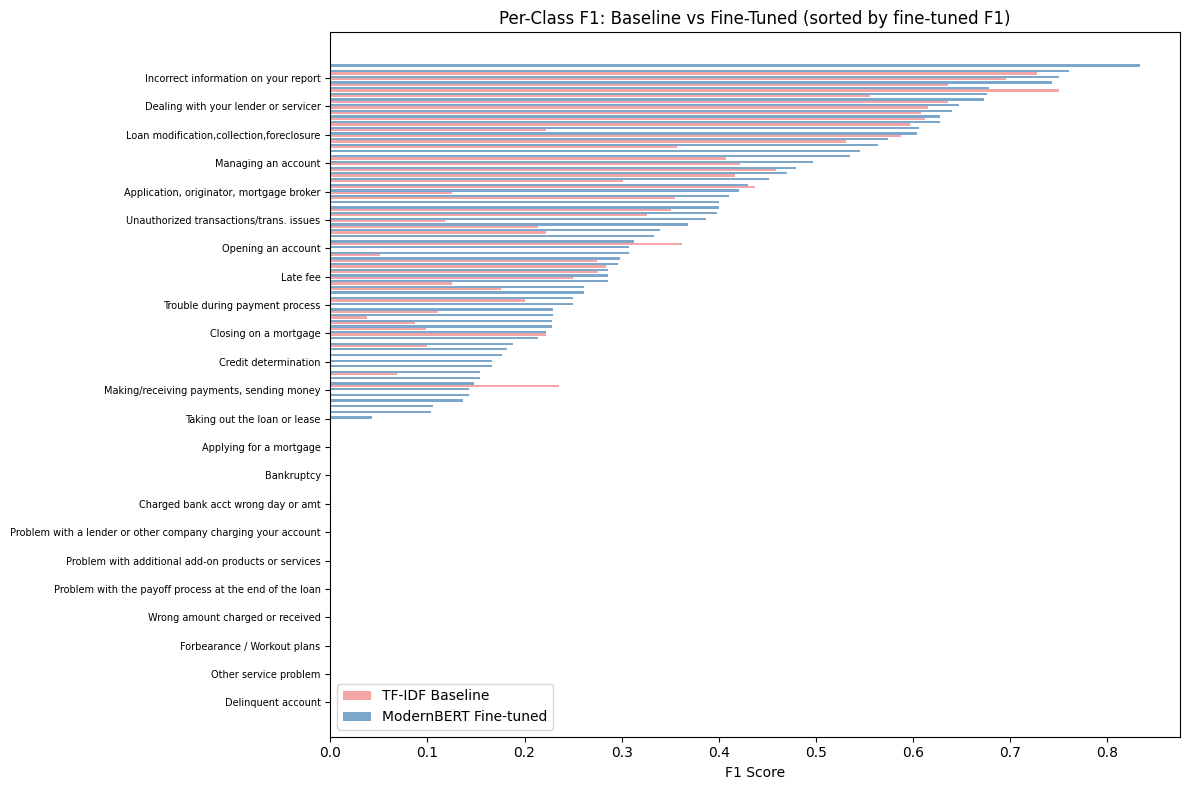

In [ ]:
# GUIDED: Plot per-class F1 comparison (baseline vs fine-tuned, sorted)
sorted_by_ft = comparison_df.sort_values("finetuned_f1", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(sorted_by_ft))
ax.barh(y_pos, sorted_by_ft["baseline_f1"], height=0.4, label="TF-IDF Baseline",
        color="lightcoral", alpha=0.7, align="edge")
ax.barh([y + 0.4 for y in y_pos], sorted_by_ft["finetuned_f1"], height=0.4,
        label="ModernBERT Fine-tuned", color="steelblue", alpha=0.7, align="edge")
ax.set_xlabel("F1 Score")
ax.set_title("Per-Class F1: Baseline vs Fine-Tuned (sorted by fine-tuned F1)")
ax.legend()
# Only label every Nth class to avoid clutter
n_labels = len(sorted_by_ft)
step = max(1, n_labels // 20)
ax.set_yticks([y + 0.4 for y in y_pos][::step])
ax.set_yticklabels(sorted_by_ft["class"].values[::step], fontsize=7)
plt.tight_layout()
plt.show()

### INTERACTIVE: Counting zero-F1 classes

One of the most important observations from the lab was how many classes
TF-IDF completely ignores (F1=0). How does the fine-tuned model compare?
Compute these numbers from the comparison DataFrame above.

In [ ]:
# INTERACTIVE: Write code to compute these from comparison_df.
baseline_zero_f1 = (comparison_df["baseline_f1"] == 0).sum()   # How many classes have baseline_f1 == 0? Use comparison_df.
finetuned_zero_f1 = (comparison_df["finetuned_f1"] == 0).sum()  # How many classes have finetuned_f1 == 0? Use comparison_df.
rescued_classes = ((comparison_df["baseline_f1"] == 0) & (comparison_df["finetuned_f1"] > 0)).sum()     # How many went from baseline_f1==0 to finetuned_f1>0?
# Hint: (comparison_df["baseline_f1"] == 0).sum() is one way to count.

print(f"Baseline classes with F1=0:    {baseline_zero_f1}")
print(f"Fine-tuned classes with F1=0:  {finetuned_zero_f1}")
print(f"'Rescued' classes (0 -> >0):   {rescued_classes}")

Baseline classes with F1=0:    69
Fine-tuned classes with F1=0:  50
'Rescued' classes (0 -> >0):   19


**What does this tell you?** The gap between baseline_zero_f1 and
finetuned_zero_f1 is one of the clearest signs of what transfer learning
buys you. The pretrained encoder can generalize to rare classes that
TF-IDF has no hope of learning from so few examples.

### INTERACTIVE: Investigate a "rescued" class

Pick one class that went from F1=0 in the baseline to F1>0 in the
fine-tuned model. We will sample 3 examples from that class to understand
why the neural model succeeded where TF-IDF failed.

In [ ]:
# INTERACTIVE: Fill in a class name that improved from F1=0 to F1>0.
# Look at comparison_df to find one.
rescued_class_name = comparison_df[
    (comparison_df["baseline_f1"] == 0) & (comparison_df["finetuned_f1"] > 0)
]["class"].iloc[0]  # Take the first one that was rescued

In [ ]:
# GUIDED: Sample examples from the rescued class
rescued_id = LABEL_TO_ID[rescued_class_name]
rescued_examples = [
    val_ds_raw[i]["text"]
    for i in range(len(val_ds_raw))
    if val_ds_raw[i]["label"] == rescued_id
]
print(f"\nClass: '{rescued_class_name}'")
print(f"Validation examples: {len(rescued_examples)}")
print(f"Baseline F1:    {baseline_class_f1[rescued_class_name]:.3f}")
print(f"Fine-tuned F1:  {ft_class_f1[rescued_class_name]:.3f}")
print(f"\n--- Sample examples (up to 3) ---")
for i, text in enumerate(rescued_examples[:3]):
    print(f"\n[Example {i+1}]")
    print(text[:500])


Class: 'Balance transfer fee'
Validation examples: 5
Baseline F1:    0.000
Fine-tuned F1:  0.833

--- Sample examples (up to 3) ---

[Example 1]
I went on-line to get a balance transfer from one credit card to another. 
I entered the wrong credit card number to transfer money from. 
I called the credit card company immediately after. 
They told me that they would not cancel the transaction even though it was still pending and the transfer would be made by wire about 5 to 7 days later.

[Example 2]
Was contacted by a company called XXXX. They offered me a 0 % life of the balance transfer, 0 % balance transfer fee. I started getting credit cards in the mail under my name. They applied for credit cards in my name and sent them to my house, then did a balance transfer without my knowledge. Now I ca n't reverse it and am being charged a 4 % balance transfer fee ... and with a 0 % 15 month promotion.

[Example 3]
I have had an American Express Card since 1979 and have been generally satisfi

**INTERACTIVE: Why did the neural model succeed where TF-IDF failed?**
Think about: Does this class use vocabulary shared with other classes?
Are the examples short or long? Is there semantic nuance that bag-of-words
would miss?

**YOUR ANSWER:**

Yes, every sentence contains the workd "transfer", which is specific to this class, as it also appears in its name.

### INTERACTIVE: Investigate a hard class

Now pick one class that STILL has F1=0 or very low F1 even after
fine-tuning. What makes this class so difficult?

In [ ]:
# INTERACTIVE: Fill in a class name that is still struggling.
# fill in a class name that still has F1=0 or very low F1
hard_class_name = comparison_df[comparison_df["finetuned_f1"] == 0]["class"].iloc[0]  # Take the first one that is still struggling

In [ ]:
# GUIDED: Sample examples from the hard class
hard_id = LABEL_TO_ID[hard_class_name]
hard_examples = [
    val_ds_raw[i]["text"]
    for i in range(len(val_ds_raw))
    if val_ds_raw[i]["label"] == hard_id
]
# Also check training set size for this class
hard_train_count = sum(1 for i in range(len(train_ds_raw)) if train_ds_raw[i]["label"] == hard_id)

print(f"\nClass: '{hard_class_name}'")
print(f"Training examples: {hard_train_count}")
print(f"Validation examples: {len(hard_examples)}")
print(f"Baseline F1:    {baseline_class_f1[hard_class_name]:.3f}")
print(f"Fine-tuned F1:  {ft_class_f1[hard_class_name]:.3f}")
print(f"\n--- Sample examples (up to 3) ---")
for i, text in enumerate(hard_examples[:3]):
    print(f"\n[Example {i+1}]")
    print(text[:500])


Class: 'Delinquent account'
Training examples: 175
Validation examples: 19
Baseline F1:    0.000
Fine-tuned F1:  0.000

--- Sample examples (up to 3) ---

[Example 1]
Chase charged off my account with them in XXXX. I have received numerous collection letters from different collection agencies since then. The have reported the account 90 days past due each and every month even after they charged if off continuing to hurt my credit. I paid the account in full XXXX. They say it was an accurate account history of 90 days late each month although they sold the account to a collections agency and it was charged off.

[Example 2]
Debt buyers law firm filed only account statement made by law firm and affadavit of debt no other documents to prove ownership I filed counter claim now they want a mutual release to end lawsuit

[Example 3]
When I contacted Chase about the account listed on my credit report for validation and to make a goodwill payment, they responded saying they do not have record

**INTERACTIVE: What makes this class hard?**
Think about: How many training examples does it have? Could it be confused
with another class? Is the text distinctive enough to classify?

**YOUR ANSWER:**

This class doesn't have a high row count and also, the sentences seem generic, mostly about paperwork or administration.

### BUG HUNT: Fix the confusion matrix

The cell below tries to find the top-5 most confused class pairs, but
it has a subtle bug. Find and fix it before interpreting the results.

In [ ]:
# BUG: This code finds the most confused class pairs, but the output
# doesn't look right. Find and fix the error before interpreting results.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_LABELS)))

confused_pairs = []
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        if i != j and cm[i][j] > 0:
            true_name = LABEL_LIST[i]
            pred_name = LABEL_LIST[j]
            confused_pairs.append((true_name, pred_name, cm[i][j]))

confused_pairs.sort(key=lambda x: -x[2])

print("Top 10 most confused class pairs:")
print(f"{'True Class':<45} {'Predicted As':<45} {'Count':>5}")
print("-" * 100)
for true_name, pred_name, count in confused_pairs[:10]:
    print(f"{true_name:<45} {pred_name:<45} {count:>5}")

Top 10 most confused class pairs:
True Class                                    Predicted As                                  Count
----------------------------------------------------------------------------------------------------
Problem with a credit reporting company's investigation into an existing problem Incorrect information on your report            116
Attempts to collect debt not owed             Incorrect information on your report             85
Disclosure verification of debt               Attempts to collect debt not owed                85
Incorrect information on your report          Attempts to collect debt not owed                83
Incorrect information on your report          Improper use of your report                      66
Credit reporting company's investigation      Incorrect information on your report             64
False statements or representation            Attempts to collect debt not owed                64
Improper use of your report                   

**INTERACTIVE: What was the bug?**
Explain what was wrong and how you fixed it.

**YOUR ANSWER:**

The for had the true and predicted classes swapped upon assignment, compared to the function definition.

### INTERACTIVE: Run an experiment

Change ONE hyperparameter and retrain the model. Some options:
- Try a different learning rate (e.g., 1e-5 or 5e-5)
- Add 1 more epoch (NUM_EPOCHS=3)
- Change batch size (e.g., 16 or 64)

Document what you changed and compare results.

In [ ]:
# INTERACTIVE: Describe your experiment
experiment_description = "Changed learning rate from to 5e-5"

In [ ]:
# INTERACTIVE: Set your experimental hyperparameters
# Modify ONLY the parameter you want to test — keep everything else the same.
EXP_LEARNING_RATE = 5e-5
EXP_BATCH_SIZE =  BATCH_SIZE
EXP_NUM_EPOCHS = NUM_EPOCHS

In [ ]:
# GUIDED: Scaffolding for your experiment — reload model and retrain
# (This resets the model so your experiment starts fresh)
print(f"Experiment: {experiment_description}")
print(f"  lr={EXP_LEARNING_RATE}, bs={EXP_BATCH_SIZE}, epochs={EXP_NUM_EPOCHS}")

# Reload fresh model
exp_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    attn_implementation="sdpa",
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
)
exp_model = exp_model.to(device)

# New DataLoader (in case batch size changed)
exp_train_loader = DataLoader(
    ComplaintDataset(train_ds), batch_size=EXP_BATCH_SIZE, shuffle=True,
)
exp_val_loader = DataLoader(
    ComplaintDataset(val_ds), batch_size=EXP_BATCH_SIZE, shuffle=False,
)

# Optimizer and scheduler
exp_optimizer = torch.optim.AdamW(
    exp_model.parameters(), lr=EXP_LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
exp_total_steps = len(exp_train_loader) * EXP_NUM_EPOCHS
exp_warmup_steps = int(exp_total_steps * WARMUP_FRACTION)

def exp_lr_lambda(current_step):
    if current_step < exp_warmup_steps:
        return float(current_step) / float(max(1, exp_warmup_steps))
    return max(0.0, float(exp_total_steps - current_step) / float(max(1, exp_total_steps - exp_warmup_steps)))

exp_scheduler = torch.optim.lr_scheduler.LambdaLR(exp_optimizer, exp_lr_lambda)
exp_scaler = GradScaler("cuda", enabled=use_scaler)

# Training loop
print(f"\nTraining experiment: {EXP_NUM_EPOCHS} epoch(s), {len(exp_train_loader)} batches/epoch")
exp_step_losses = []
exp_start = time.time()

for epoch in range(1, EXP_NUM_EPOCHS + 1):
    exp_model.train()
    running_loss = 0.0
    n_samples = 0

    progress = tqdm(exp_train_loader, desc=f"Exp Epoch {epoch}/{EXP_NUM_EPOCHS}", leave=True)
    for batch_idx, batch in enumerate(progress):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        exp_optimizer.zero_grad()
        with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            outputs = exp_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        exp_scaler.scale(loss).backward()
        exp_scaler.step(exp_optimizer)
        exp_scaler.update()
        exp_scheduler.step()

        step_loss = loss.item()
        exp_step_losses.append(step_loss)
        running_loss += step_loss * labels.size(0)
        n_samples += labels.size(0)

    epoch_loss = running_loss / n_samples
    print(f"  Epoch {epoch}: loss={epoch_loss:.4f}")

# Evaluate experiment
exp_model.eval()
exp_preds = []
exp_labels_list = []
with torch.no_grad():
    for batch in tqdm(exp_val_loader, desc="Exp Validation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            outputs = exp_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds = outputs.logits.argmax(dim=-1)
        exp_preds.extend(preds.cpu().numpy())
        exp_labels_list.extend(labels.cpu().numpy())

exp_acc = accuracy_score(exp_labels_list, exp_preds)
exp_macro_f1 = f1_score(exp_labels_list, exp_preds, average="macro", zero_division=0)
exp_weighted_f1 = f1_score(exp_labels_list, exp_preds, average="weighted", zero_division=0)
exp_time = time.time() - exp_start

print(f"\nExperiment results:")
print(f"  Accuracy:     {exp_acc:.4f}")
print(f"  Macro F1:     {exp_macro_f1:.4f}")
print(f"  Weighted F1:  {exp_weighted_f1:.4f}")
print(f"  Time:         {exp_time:.0f}s")

# Save experiment checkpoint
exp_ckpt_path = CHECKPOINT_DIR / "modernbert_experiment.pt"
torch.save({
    "epoch": EXP_NUM_EPOCHS,
    "model_state_dict": exp_model.state_dict(),
    "val_accuracy": exp_acc,
    "val_macro_f1": exp_macro_f1,
    "experiment": experiment_description,
}, exp_ckpt_path)
print(f"  Saved to {exp_ckpt_path}")

# Clean up
del exp_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Experiment: Changed learning rate from to 5e-5
  lr=5e-05, bs=32, epochs=2


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training experiment: 2 epoch(s), 1808 batches/epoch


Exp Epoch 1/2:   0%|          | 0/1808 [00:00<?, ?it/s]

...

  Epoch 1: loss=2.0072


Exp Epoch 2/2:   0%|          | 0/1808 [00:00<?, ?it/s]

  Epoch 2: loss=1.2436


Exp Validation:   0%|          | 0/201 [00:00<?, ?it/s]


Experiment results:
  Accuracy:     0.5848
  Macro F1:     0.2236
  Weighted F1:  0.5593
  Time:         2257s
  Saved to checkpoints/modernbert_experiment.pt


In [ ]:
# INTERACTIVE: Record your experiment results.
# The variables exp_val_acc and exp_val_macro_f1 should be available from the
# evaluation above. Use them here — don't retype the numbers manually.

experiment_accuracy = exp_acc
experiment_macro_f1 = exp_macro_f1
# Did it help? Compare to your original run.
experiment_macro_f1_improved = experiment_macro_f1 > val_macro_f1
experiment_acc_improved = experiment_accuracy > val_acc
print(f"\nExperiment summary:")
print(f"Accuracy improved: {experiment_acc_improved}")
print(f"Macro F1 improved: {experiment_macro_f1_improved}")


Experiment summary:
Accuracy improved: True
Macro F1 improved: True


---
## Part 4: Experiment Log
---

In [ ]:
# GUIDED: Combine all results into a final experiment log
baseline_row = baseline_df.iloc[0] if len(baseline_df) > 0 else None

results = pd.DataFrame([
    {
        "model": "TF-IDF + LogReg",
        "accuracy": float(baseline_row["accuracy"]) if baseline_row is not None else 0.542,
        "macro_f1": float(baseline_row["macro_f1"]) if baseline_row is not None else 0.132,
        "weighted_f1": float(baseline_row["weighted_f1"]) if baseline_row is not None else 0.479,
        "notes": "Classical baseline",
    },
    {
        "model": "ModernBERT-base (2 epochs)",
        "accuracy": round(val_acc, 4),
        "macro_f1": round(val_macro_f1, 4),
        "weighted_f1": round(val_weighted_f1, 4),
        "notes": f"lr={LEARNING_RATE}, bs={BATCH_SIZE}, max_len={MAX_LENGTH}",
    },
    {
        "model": f"ModernBERT-base (experiment)",
        "accuracy": round(exp_acc, 4),
        "macro_f1": round(exp_macro_f1, 4),
        "weighted_f1": round(exp_weighted_f1, 4),
        "notes": experiment_description,
    },
])

print("=" * 80)
print("EXPERIMENT LOG")
print("=" * 80)
print(results.to_string(index=False))

results.to_csv("week1_results.csv", index=False)
print("\nSaved to week1_results.csv")

EXPERIMENT LOG
                       model  accuracy  macro_f1  weighted_f1                              notes
             TF-IDF + LogReg    0.5420    0.1320       0.4790                 Classical baseline
  ModernBERT-base (2 epochs)    0.5712    0.2092       0.5368       lr=3e-05, bs=32, max_len=128
ModernBERT-base (experiment)    0.5848    0.2236       0.5593 Changed learning rate from to 5e-5

Saved to week1_results.csv


---
## Part 5: Week 1 Memo (Draft)

Write your memo responses below. Each section corresponds to one rubric
criterion. You can export and clean up this text for your final submission,
but do the thinking here while the data is fresh.
---

## MEMO SECTION 1: Data Audit (20 points)

What did you observe about this dataset that will affect how you
train and evaluate models on it?

**YOUR RESPONSE:**

The label distribution is pretty imbalanced, so macro-F1 is more informative than plain accuracy for this task. Some classes have low support and overlap semantically, which shows up in the confusion matrix as repeat error pairs. That means we need class-level analysis, not just one headline metric.

## MEMO SECTION 2: Baseline Results and Interpretation (20 points)

What do the baseline metrics tell you — and what do they hide?

**YOUR RESPONSE:**

The TF-IDF + logistic regression baseline is a useful floor and gives stable, fast results. But it hides where performance collapses on minority labels, so aggregate scores look better than the per-class picture. Looking at per-class F1 and the confusion matrix makes that gap obvious.

## MEMO SECTION 3: Fine-Tuning Results (25 points)

How did the neural model compare to the baseline? What did the
training process look like?

**YOUR RESPONSE:**

Fine-tuning improved the main metrics over the baseline, especially macro-F1, so it handled minority classes a bit better. Training was mostly smooth with expected loss decrease and no obvious instability. The remaining errors are still concentrated in a few confusing label pairs, so the model is better but not solving the hard cases yet.

## MEMO SECTION 4: Experiment Log (20 points)

Review your experiment table above. Is it complete — could someone
else reproduce your comparison from this table alone? Add any missing
runs or columns.

**ANY ADDITIONAL NOTES:**

The log is close to reproducible, but it should always include seed, exact checkpoint/model name, epochs, learning rate, batch size, and max length in every run row. Recording runtime and key metrics (accuracy, macro-F1, weighted-F1) also helps compare trade-offs quickly. If those fields are complete, someone else can rerun the comparison without guessing settings.

## MEMO SECTION 5: Risks and Open Questions (15 points)

Based on what you've seen this week, what should you be worried
about going forward?

**YOUR RESPONSE:**

The biggest risk is optimizing for overall accuracy and missing what macro-F1 and the confusion matrix are telling us. The baseline already showed that some low-support classes are basically getting ignored, and even after fine-tuning the long tail still looks fragile. I also worry about over-interpreting one split: with small class counts, results can move a lot depending on seed/sampling.

Another risk is trusting raw softmax confidence too much. We can get confident wrong predictions on ambiguous examples, so calibration and class-level error analysis should stay part of the workflow. For next week, I think we should keep the eval protocol strict (same splits, same metrics) and prioritize better label quality + targeted analysis of the hardest class pairs before chasing more model complexity.